# Predicting Product Sales
## Decision Tree



### 1 Problem statement
An e-commerce company wants to predict the sales of their products to optimize inventory management and marketing strategies.
This is a regression problem, where:
  Input: Product and transaction features (quantity, unit price, country, etc.)
  Output: Revenue (numerical value)


### 2 Data collection
Dataset Source - Online Retail Dataset from Kaggle
It contains transactional data from an online retail store including:
  InvoiceNo: Invoice number
  StockCode: Product code
  Description: Product description
  Quantity: Number of units purchased
  InvoiceDate: Date of purchase
  UnitPrice: Price per unit
  CustomerID: Customer identifier
  Country: Country of purchase


#### 2.1 Import data and Required Packages


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # ẩn các cảnh báo


In [6]:
df = pd.read_excel("Copy of Online Retail.xlsx")

In [7]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.shape


(541909, 8)

### 3. Data checks to perform
Before training the model, several checks are performed:
Check for missing value
Check duplicate entries
Verify data types
Check distribution of target variable


In [9]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Description thiếu 1454 giá trị, CustomerID thiếu 135080 giá trị

In [10]:
df.duplicated().sum()


np.int64(5268)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [12]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Quantity có giá trị âm (đơn hàng bị trả lại), UnitPrice cũng có vài giá trị âm cần xử lý

### 4. Feature Engineering


In [13]:
# tạo target variable: Revenue = Quantity * UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# tách thông tin thời gian từ InvoiceDate
df['Year']  = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day']   = df['InvoiceDate'].dt.day
df['Hour']  = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,2


### 5. Visualization


#### 5.1 Distribution of Revenue


Revenue is right-skewed with most transactions having low revenue and a few high-value outliers


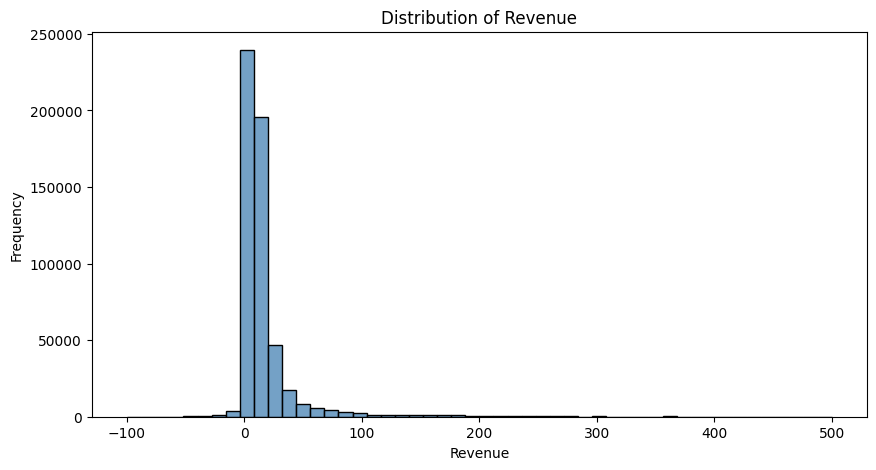

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Revenue'].between(-100, 500)]['Revenue'], bins=50, color='steelblue')
plt.title('Distribution of Revenue')
plt.xlabel('Revenue') #nhãn trục x
plt.ylabel('Frequency') #nhãn trục y
plt.show()

#### 5.2 Top 10 Countries by Revenue


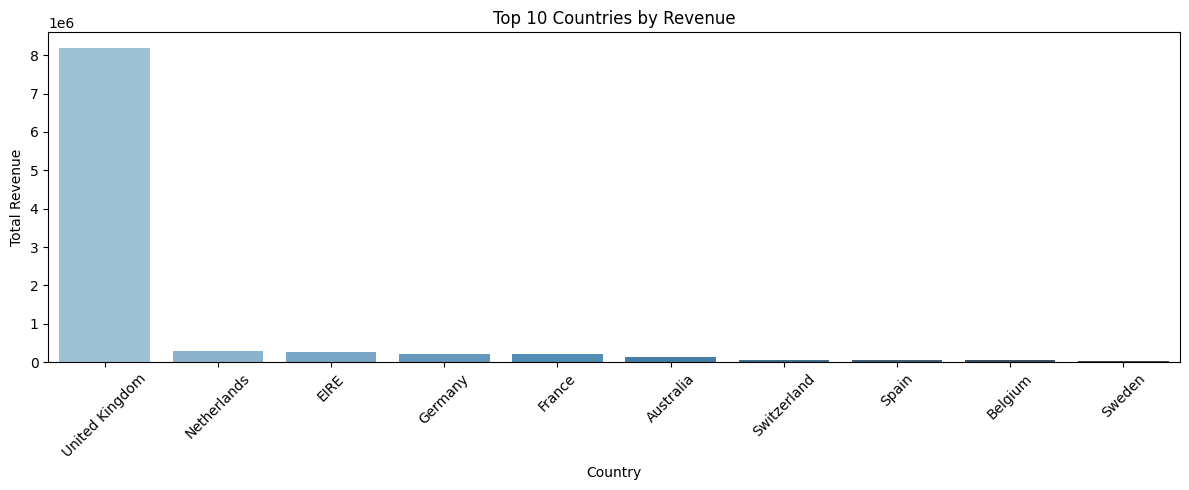

In [15]:
country_rev = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=country_rev.index, y=country_rev.values, palette="Blues_d")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


United Kingdom dominates the revenue, followed by Netherlands and EIRE


#### 5.3 Revenue by Month


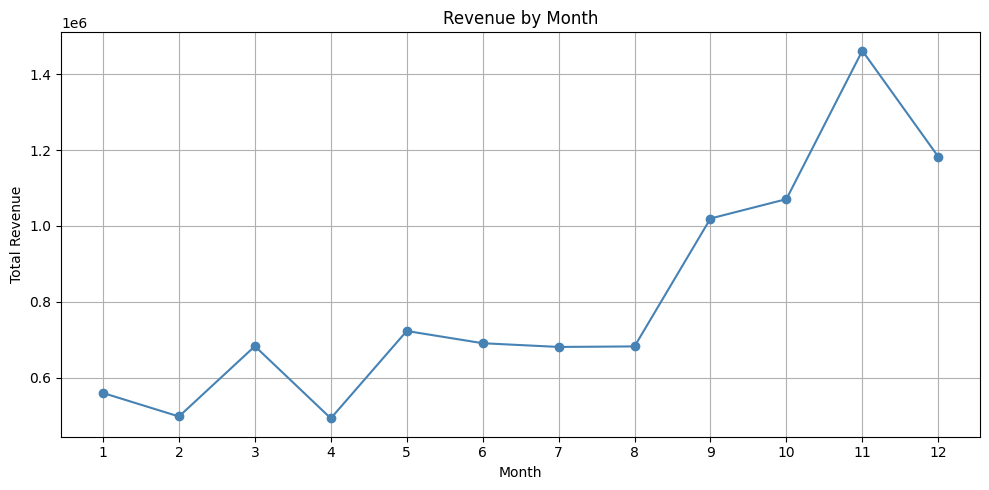

In [16]:
monthly_rev = df.groupby("Month")["Revenue"].sum()
plt.figure(figsize=(10, 5))
plt.plot(monthly_rev.index, monthly_rev.values, marker="o", color="steelblue")
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()


Revenue peaks in November, likely due to holiday shopping season


#### 5.4 Quantity vs Revenue


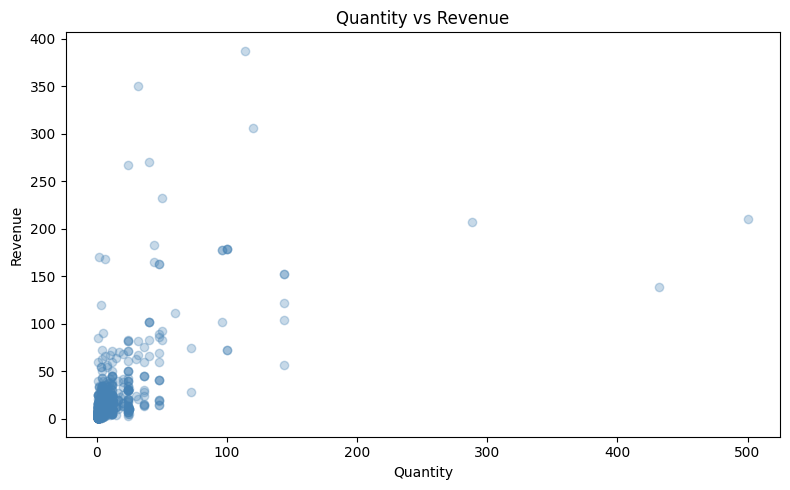

In [17]:
sample = df[(df["Quantity"] > 0) & (df["Revenue"] > 0) & (df["Revenue"] < 500)].sample(1000, random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample["Quantity"], sample["Revenue"], alpha=0.3, color="steelblue")
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


### Conclusion
dataset có 541,909 giao dịch, một số missing values và giá trị âm từ đơn hàng bị trả.
Revenue lệch phải, phần lớn giao dịch có giá trị nhỏ.
United Kingdom chiếm phần lớn doanh thu.
Có xu hướng tăng mạnh vào tháng 11.

### 6. Data Preprocessing
Data preprocessing is performed to clean and transform raw data into a suitable format for model training.


In [18]:
# loại bỏ các đơn hàng bị huỷ (InvoiceNo bắt đầu bằng "C")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# loại bỏ các dòng có Quantity và UnitPrice âm hoặc bằng 0
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# loại bỏ missing values
df = df.dropna(subset=["CustomerID"])

print("Shape after cleaning:", df.shape)


Shape after cleaning: (397884, 14)


In [19]:
# encode Country thành số
countries = df["Country"].unique()
country_map = {c: i for i, c in enumerate(countries)}
df["Country_encoded"] = df["Country"].map(country_map)

# chọn features và target
features = ["Quantity", "UnitPrice", "Month", "Day", "Hour", "DayOfWeek", "Country_encoded"]
target   = "Revenue"

X = df[features].values
y = df[target].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (397884, 7)
y shape: (397884,)


##### Split data


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)


Train size: (318307, 7)
Test size:  (79577, 7)


### 7. Model Training


##### Decision Tree


vẽ S


In [21]:
# hàm tính variance
def variance(y):
    if len(y) == 0: return 0
    return np.var(y) #phương sai của tập y


Hàm mất mát


In [22]:
def variance_reduction(y, y_left, y_right):
    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)
    weighted_var = (n_left/n)*variance(y_left) + (n_right/n)*variance(y_right) #weighted variance 2 nhánh
    return variance(y) - weighted_var


In [23]:
def best_split(X, y):
    best_vr = -1
    best_feature = None
    best_threshold = None
    n_features = X.shape[1]
    for feature_idx in range(n_features):
        thresholds = np.unique(X[:, feature_idx]) #các giá trị unique của feature
        for threshold in thresholds:
            left_mask  = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
            y_left  = y[left_mask]
            y_right = y[right_mask]
            if len(y_left) == 0 or len(y_right) == 0: continue #bỏ qua nếu 1 nhánh rỗng
            vr = variance_reduction(y, y_left, y_right)
            if vr > best_vr:
                best_vr = vr
                best_feature = feature_idx
                best_threshold = threshold
    return best_feature, best_threshold


In [24]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature   = feature    #feature dùng để split
        self.threshold = threshold  #ngưỡng split
        self.left      = left       #nhánh trái
        self.right     = right      #nhánh phải
        self.value     = value      #giá trị dự đoán ở leaf node
    def is_leaf(self):
        return self.value is not None


In [26]:
def build_tree(X, y, depth=0, max_depth=10, min_samples=5):
    n_samples = len(y)
    if depth >= max_depth or n_samples < min_samples: #điều kiện dừng
        return Node(value=np.mean(y)) #leaf trả về giá trị trung bình
    feature, threshold = best_split(X, y) #tìm best split
    if feature is None:
        return Node(value=np.mean(y))
    left_mask  = X[:, feature] <= threshold
    right_mask = ~left_mask
    left_subtree  = build_tree(X[left_mask],  y[left_mask],  depth+1, max_depth, min_samples) #đệ quy nhánh trái
    right_subtree = build_tree(X[right_mask], y[right_mask], depth+1, max_depth, min_samples) #đệ quy nhánh phải
    return Node(feature=feature, threshold=threshold, left=left_subtree, right=right_subtree)


In [27]:
def predict_one(node, x): #hàm dự đoán 1 mẫu
    if node.is_leaf():
        return node.value
    if x[node.feature] <= node.threshold: #đi trái hoặc phải tuỳ feature
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)

def predict(node, X):
    return np.array([predict_one(node, x) for x in X])

tree = build_tree(X_train, y_train, max_depth=10, min_samples=5) #train cây
#xuất dự đoán trên tập test
y_test_pred = predict(tree, X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse  = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_test_pred)
r2   = r2_score(y_test, y_test_pred)
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


MSE : 297.6365
RMSE: 17.2521
MAE : 3.9673
R2  : 0.9494


Biểu đồ Decision Tree


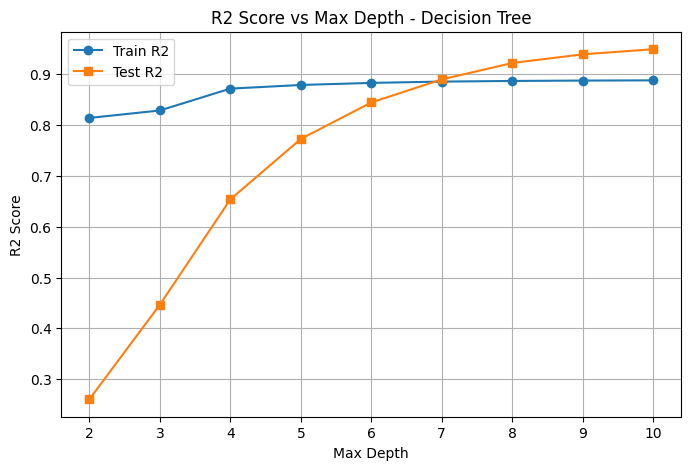

In [28]:
depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
r2_train_list = []
r2_test_list  = []

for d in depths:
    t = build_tree(X_train, y_train, max_depth=d, min_samples=5)
    r2_train_list.append(r2_score(y_train, predict(t, X_train)))
    r2_test_list.append(r2_score(y_test,  predict(t, X_test)))

plt.figure(figsize=(8,5))
plt.plot(depths, r2_train_list, marker='o', label='Train R2') #vẽ đường train
plt.plot(depths, r2_test_list,  marker='s', label='Test R2')  #vẽ đường test
plt.xlabel("Max Depth") #nhãn trục x
plt.ylabel("R2 Score")  #nhãn trục y
plt.title("R2 Score vs Max Depth - Decision Tree")
plt.legend()
plt.grid(True) #hiển thị lưới để dễ đọc giá trị
plt.savefig("depth_vs_r2.png", dpi=300, bbox_inches='tight') #lưu biểu đồ
plt.show()


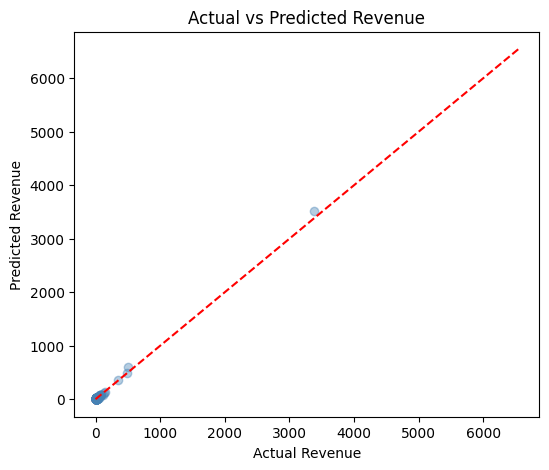

In [29]:
# Vẽ biểu đồ Actual vs Predicted
sample_idx = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(6,5))
plt.scatter(y_test[sample_idx], y_test_pred[sample_idx], alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') #đường lý tưởng
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue") #nhãn trục x
plt.ylabel("Predicted Revenue") #nhãn trục y
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()
